# MERSCOPE

In [1]:
import warnings
warnings.filterwarnings("ignore")
import MENDER
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.metrics import *


In [2]:
import pysodb
sodb = pysodb.SODB()
adata_dict = sodb.load_dataset('Dataset13_MS_raw')
adata = list(adata_dict.values())[0]

load experiment[Dataset13] in dataset[Dataset13_MS_raw]


In [3]:
adata_raw = adata.copy()

In [4]:
batch_obs = 'slice_id'


In [5]:
%%time
scale = 6
radius = 15


adata = adata_raw.copy()

# main body of MENDER
msm = MENDER.MENDER(
    adata,
    batch_obs = batch_obs, 
    # determine which cell state to use
    # we use the cell state got by Leiden
    ct_obs='ct',
    random_seed=666
)


# set the MENDER parameters


msm.prepare()
msm.set_MENDER_para(
    # default of n_scales is 6
    n_scales=scale, 

    # for single cell data, nn_mode is set to 'radius' 
    nn_mode='radius',

    # default of n_scales is 15 um (see the manuscript for why).
    # MENDER also provide a function 'estimate_radius' for estimating the radius
    nn_para=radius, 

)
# construct the context representation
msm.run_representation_mp(
    200
    # the number of processings
)

# set the spatial clustering parameter
# positive values for the expected number of domains
# negative values for the clustering resolution
msm.run_clustering_normal(-1.5)




default number of process is 200
total batch: 9, running batch R1S1
total batch: 9, running batch R1S2
total batch: 9, running batch R1S3
total batch: 9, running batch R2S1
scale 0, median #cells per radius (r=15): 2.0
total batch: 9, running batch R2S2
scale 0, median #cells per radius (r=15): 2.0
total batch: 9, running batch R2S3
scale 0, median #cells per radius (r=15): 2.0
total batch: 9, running batch R3S1
scale 0, median #cells per radius (r=15): 2.0
total batch: 9, running batch R3S2
scale 1, median #cells per radius (r=15): 4.0
scale 0, median #cells per radius (r=15): 2.0
total batch: 9, running batch R3S3
scale 1, median #cells per radius (r=15): 4.0
scale 1, median #cells per radius (r=15): 4.0
scale 0, median #cells per radius (r=15): 2.0
scale 0, median #cells per radius (r=15): 2.0
scale 0, median #cells per radius (r=15): 2.0
scale 1, median #cells per radius (r=15): 4.0
scale 0, median #cells per radius (r=15): 2.0
scale 2, median #cells per radius (r=15): 7.0
scale 1,

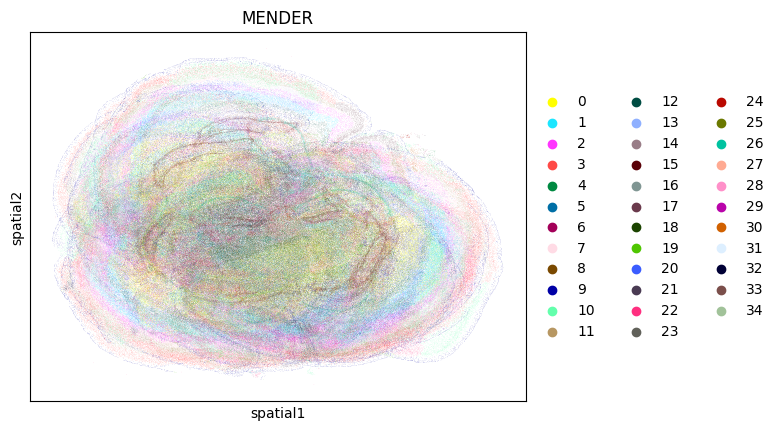

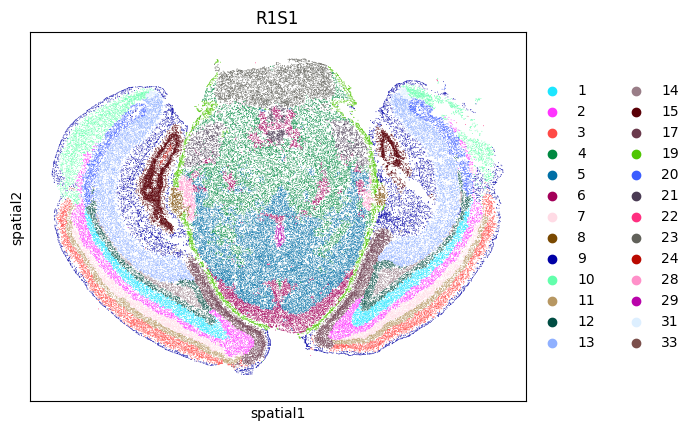

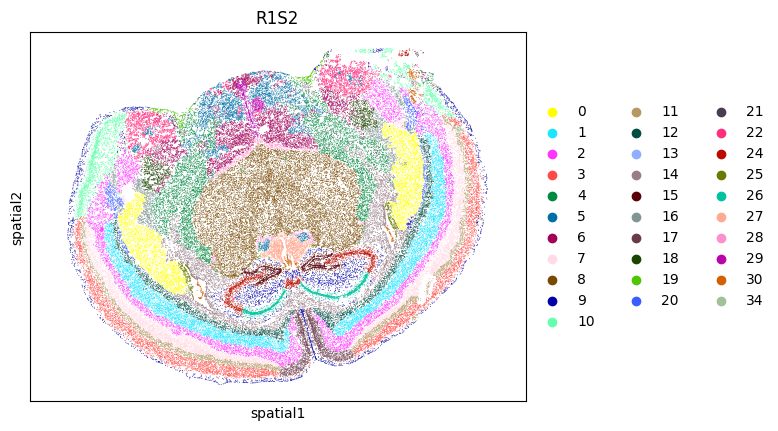

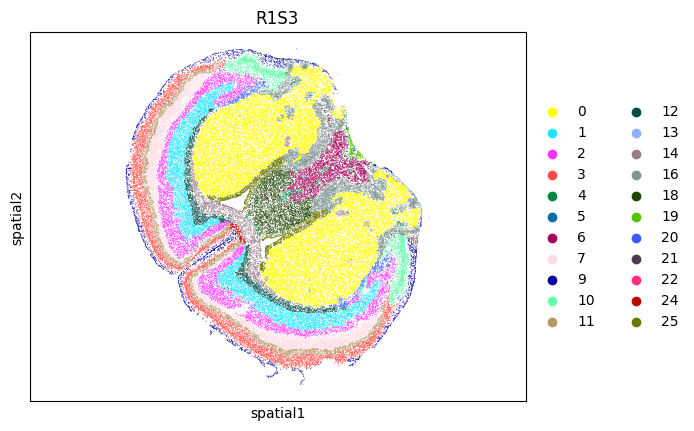

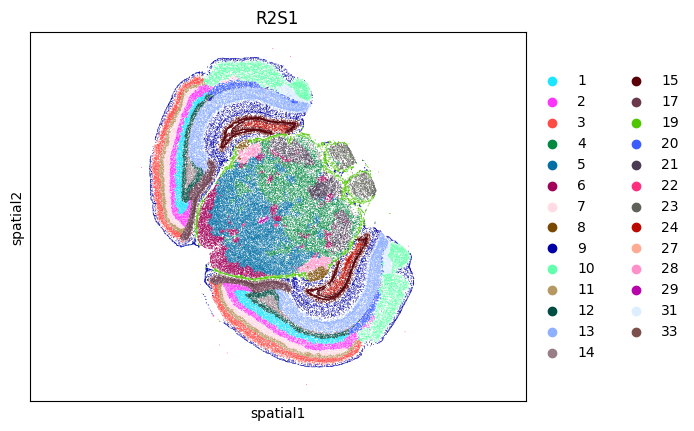

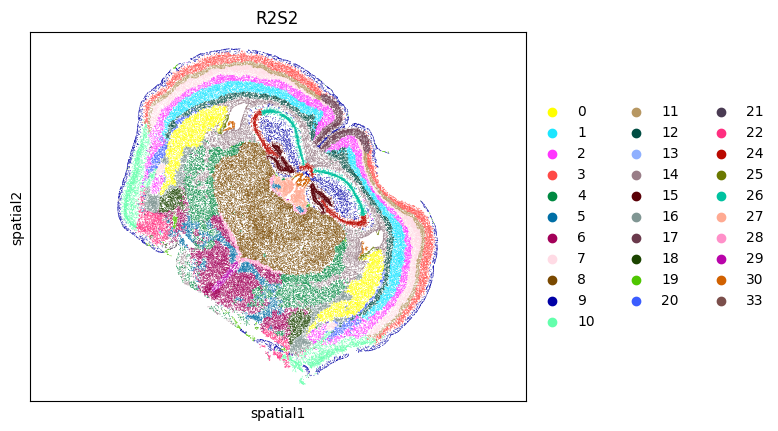

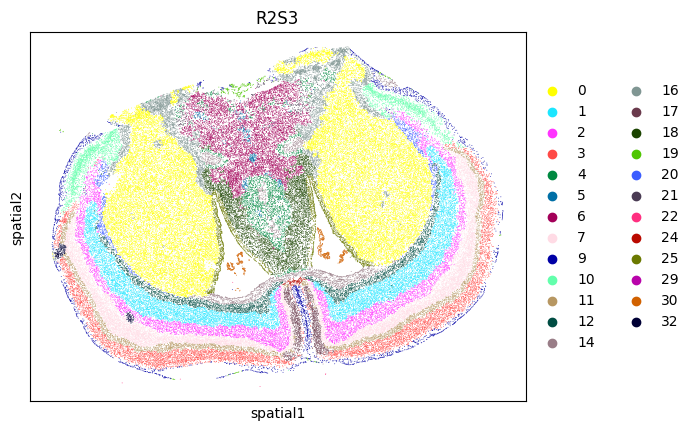

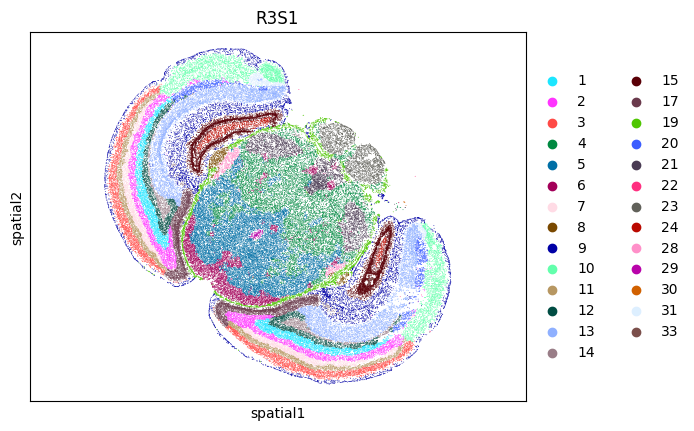

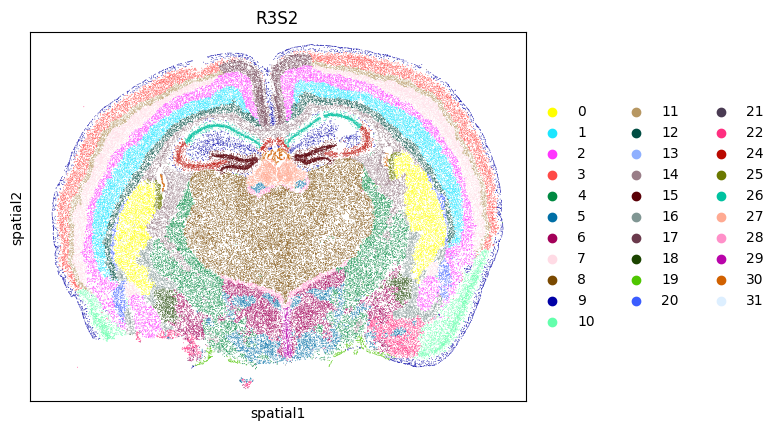

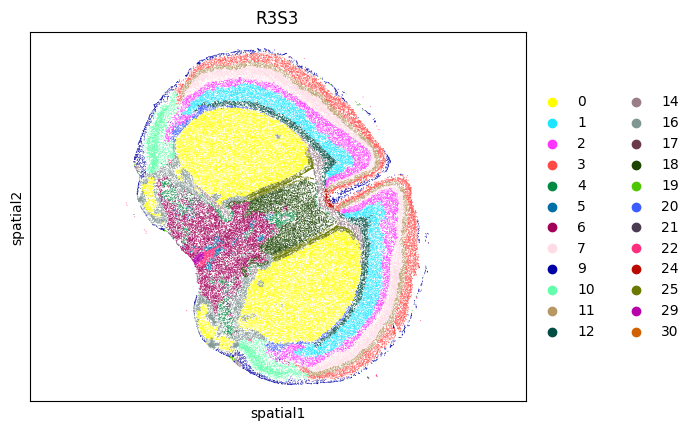

In [6]:
msm.output_cluster_all(obs='MENDER',obs_gt=None)

msm.adata_MENDER.write_h5ad(f'dump/MERSCOPE_brain.h5ad')
